# Final Project

This notebook is adapted from here: https://aiqm.github.io/torchani/examples/nnp_training.html

## Checkpoint 1: Data preparation

1. Create a working directory: `/global/scratch/users/[USER_NAME]/[DIR_NAME]`. Replace the [USER_NAME] with yours and specify a [DIR_NAME] you like.
2. Copy the Jupyter Notebook to the working directory
3. Download the ANI dataset `ani_dataset_gdb_s01_to_s04.h5` from bCourses and upload it to the working directory

In [1]:
pip install torchani==2.2.3

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torchani
print(torchani.__version__)
from torchani.data import load
import matplotlib.pyplot as plt

/opt/anaconda3/envs/c142/lib/python3.8/site-packages/torchani/aev.py:16: UserWarning: cuaev not installed
  warnings.warn("cuaev not installed")
/opt/anaconda3/envs/c142/lib/python3.8/site-packages/torchani/__init__.py:55: UserWarning: Dependency not satisfied, torchani.ase will not be available
  warnings.warn("Dependency not satisfied, torchani.ase will not be available")


2.2.3


In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
np.random.seed(43)

### Use GPU

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


### Set up AEV computer

#### AEV: Atomic Environment Vector (atomic features)

Ref: Chem. Sci., 2017, 8, 3192

In [6]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


### Prepare dataset & split

In [32]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset
    
def count_heavy_atoms(species_tensor, heavy_atom_indices={1, 2, 3}):  # 1=C, 2=N, 3=O
    return sum(1 for atom in species_tensor if atom.item() in heavy_atom_indices)

raw_dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")

# molecules with ≥ 4 heavy atoms
filtered_data = [
    datapoint for datapoint in raw_dataset
    if count_heavy_atoms(datapoint['species']) >= 4
]

filtered_dataset = torchani.data.TransformableIterable(filtered_data)

train_data, val_data, test_data = filtered_dataset.split(0.8, 0.1, 0.1)

In [8]:
print(f"Number of molecules with ≥4 heavy atoms: {len(filtered_data)}")


Number of molecules with ≥4 heavy atoms: 651936


### Batching

In [9]:
# Set batch size and collate
batch_size = 64
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

### Torchani API

In [10]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [11]:
train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

tensor(0.4233, grad_fn=<MseLossBackward0>)


## Checkpoint 2: Network Construction and Workflow Development


In [12]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model

        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")

        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch

    def train(self, train_data, val_data, early_stop=True, draw_curve=True, plot_title=None):
        self.model.train()

        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()

        loss_func = nn.MSELoss()
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf

        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for batch in train_data_loader:
                input_features = batch['species'], batch['coordinates']
                true_energies = batch['energies']

                species, coordinates = input_features
                species, coordinates, true_energies = (
                    species.to(next(self.model.parameters()).device),
                    coordinates.to(next(self.model.parameters()).device).float(),  # << add .float()
                    true_energies.to(next(self.model.parameters()).device).float()  # << add .float()
                )

                pred_energies = self.model((species, coordinates)).energies
                batch_loss = loss_func(pred_energies, true_energies)

                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()

                batch_importance = len(true_energies)
                train_epoch_loss += batch_loss.item() * batch_importance

            val_epoch_loss = self.evaluate(val_data)
            train_loss_list.append(train_epoch_loss / len(train_data))
            val_loss_list.append(val_epoch_loss / len(val_data))

            if early_stop and val_epoch_loss < lowest_val_loss:
                lowest_val_loss = val_epoch_loss
                weights = self.model.state_dict()

        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            ax.plot(range(self.epoch), train_loss_list, label='Train')
            ax.plot(range(self.epoch), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            if plot_title:
                ax.set_title(plot_title)

        if early_stop:
            self.model.load_state_dict(weights)

        return train_loss_list, val_loss_list

    def evaluate(self, data, draw_plot=False,plot_title=None):
        data_loader = data.collate(self.batch_size).cache()
        loss_func = nn.MSELoss()
        total_loss = 0.0

        if draw_plot:
            true_energies_all = []
            pred_energies_all = []

        self.model.eval()
        with torch.no_grad():
            for batch in data_loader:
                species, coordinates = batch['species'], batch['coordinates']
                true_energies = batch['energies']

                species, coordinates, true_energies = (
                    species.to(next(self.model.parameters()).device),
                    coordinates.to(next(self.model.parameters()).device).float(),  # << add .float()
                    true_energies.to(next(self.model.parameters()).device).float()  # << add .float()
                )

                pred_energies = self.model((species, coordinates)).energies
                batch_loss = loss_func(pred_energies, true_energies)

                batch_importance = len(true_energies)
                total_loss += batch_loss.item() * batch_importance

                if draw_plot:
                    true_energies_all.append(true_energies.cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.cpu().numpy().flatten())

 
        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            hartree2kcalmol = 627.5094738898777
        
            # Compute RMSE in kcal/mol
            rmse = np.sqrt(np.mean((true_energies_all - pred_energies_all)**2)) * hartree2kcalmol
        
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"RMSE: {rmse:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            if plot_title:
                ax.set_title(plot_title)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()

        return total_loss


In [13]:
from itertools import islice
import torchani

train_data_split = list(islice(train_data, 2000))  
val_data_split = list(islice(val_data, 200))      
test_data_split = list(islice(test_data, 200))     

train_data = torchani.data.TransformableIterable(train_data_split)
val_data = torchani.data.TransformableIterable(val_data_split)
test_data = torchani.data.TransformableIterable(test_data_split)

Sequential - Number of parameters: 197636
Initialize training data...


100%|███████████████████████████████████████████| 10/10 [00:02<00:00,  3.94it/s]


Final test loss: 0.020718647399917245


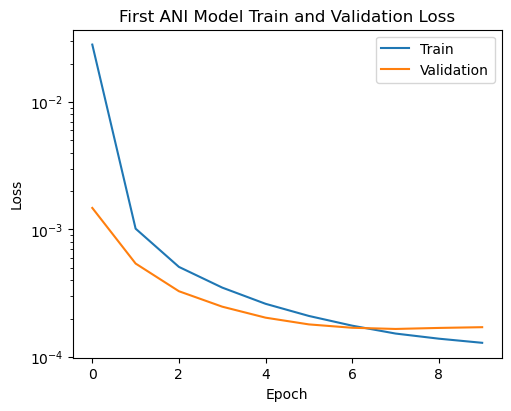

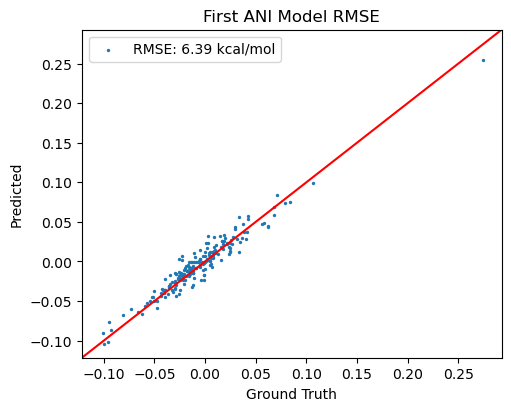

In [14]:
trainer = ANITrainer(model, batch_size=32, learning_rate=1e-3, epoch=10, l2=1e-5)

train_loss, val_loss = trainer.train(
    train_data=train_data,
    val_data=val_data,
    early_stop=True,
    draw_curve=True, 
    plot_title = "First ANI Model Train and Validation Loss"
)
test_loss = trainer.evaluate(test_data, draw_plot=True, plot_title = "First ANI Model RMSE")
print("Final test loss:", test_loss)

## Checkpoint 3: Regularization Strategies and Hyperparameter Tuning

I will be using L2 Regularization and Dropout Regularization techniques.

In [15]:
# L2 Regularization
class AtomicNetL2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.layers(x)

# Dropout Regularization 
class AtomicNetDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.layers(x)

# Dropout and L2 Regularization 
class AtomicNetDropoutAndL2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.layers(x)



Sequential - Number of parameters: 197636
Initialize training data...


100%|███████████████████████████████████████████| 20/20 [00:04<00:00,  4.82it/s]


Sequential - Number of parameters: 197636
Initialize training data...


100%|███████████████████████████████████████████| 20/20 [00:03<00:00,  5.34it/s]


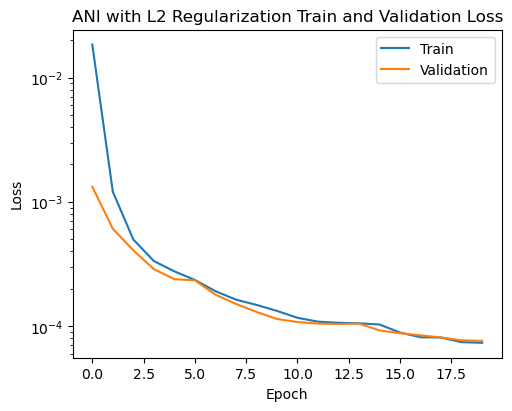

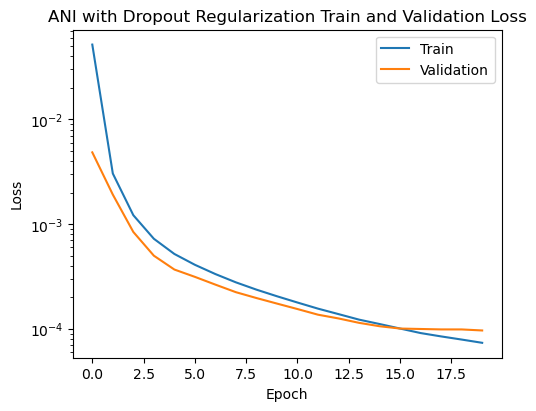

In [16]:
# Model 1: L2 regularization only
model_l2 = nn.Sequential(aev_computer, torchani.ANIModel([AtomicNetL2(), AtomicNetL2(), AtomicNetL2(), AtomicNetL2()])).to(device)
trainer_l2 = ANITrainer(model_l2, batch_size=64, learning_rate=1e-3, epoch=20, l2=1e-4)
train_loss_l2, val_loss_l2 = trainer_l2.train(train_data, val_data, plot_title = "ANI with L2 Regularization Train and Validation Loss")

# Model 2: Dropout only
model_dropout = nn.Sequential(aev_computer, torchani.ANIModel([AtomicNetDropout(), AtomicNetDropout(), AtomicNetDropout(), AtomicNetDropout()])).to(device)
trainer_dropout = ANITrainer(model_dropout, batch_size=64, learning_rate=1e-3, epoch=20, l2=0.0)
train_loss_dropout, val_loss_dropout = trainer_dropout.train(train_data, val_data, plot_title = "ANI with Dropout Regularization Train and Validation Loss")


Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 20/20 [00:04<00:00,  4.96it/s]


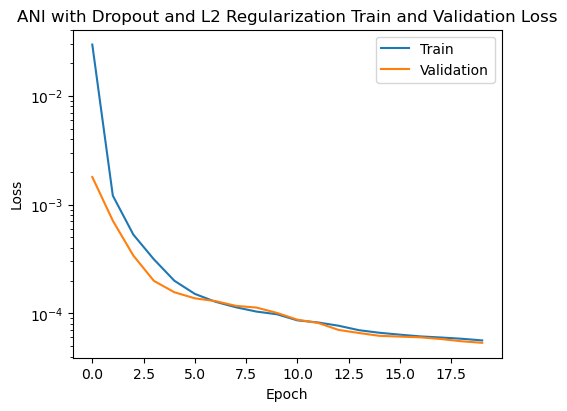

In [17]:
net_H = AtomicNetDropoutAndL2()
net_C = AtomicNetDropoutAndL2()
net_N = AtomicNetDropoutAndL2()
net_O = AtomicNetDropoutAndL2()

model_both = nn.Sequential(
    aev_computer,
    torchani.ANIModel([net_H, net_C, net_N, net_O])
).to(device)

# L2 regularization and dropout
trainer_both = ANITrainer(
    model=model_both,
    batch_size=64,
    learning_rate=1e-3,
    epoch=20,
    l2=1e-4 
)

train_loss_both, val_loss_both = trainer_both.train(train_data, val_data, draw_curve=True, plot_title = "ANI with Dropout and L2 Regularization Train and Validation Loss")


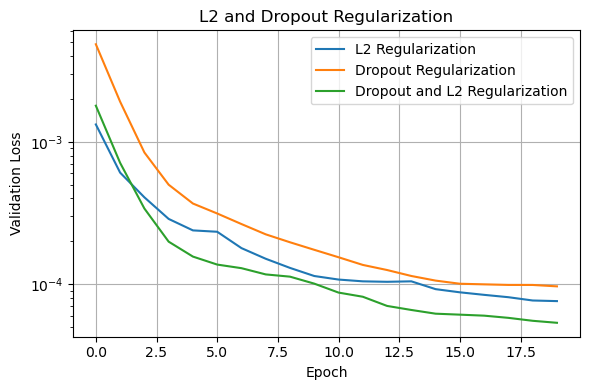

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(val_loss_l2, label='L2 Regularization')
plt.plot(val_loss_dropout, label='Dropout Regularization')
plt.plot(val_loss_both, label='Dropout and L2 Regularization')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('L2 and Dropout Regularization')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
#hyperparameter tuning 
class AtomicNetDropoutTuned(nn.Module):
    def __init__(self, dropout_rate=0.3, hidden1=256, hidden2=128):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.layers(x)

In [20]:
# Hyperparameter variables
dropouts = [0.1, 0.3, 0.5]
learning_rates = [1e-2, 1e-3, 5e-4]
batch_sizes = [32, 64]
results = []

for dropout in dropouts:
    for lr in learning_rates:
        for batch_size in batch_sizes:
            print(f"Training with dropout={dropout}, lr={lr}, batch={batch_size}")
            
            model = nn.Sequential(
                aev_computer,
                torchani.ANIModel([
                    AtomicNetDropoutTuned(dropout),
                    AtomicNetDropoutTuned(dropout),
                    AtomicNetDropoutTuned(dropout),
                    AtomicNetDropoutTuned(dropout)
                ])
            ).to(device)

            trainer = ANITrainer(
                model=model,
                batch_size=batch_size,
                learning_rate=lr,
                epoch=20,
                l2=0.0
            )
            
            _, val_loss = trainer.train(train_data, val_data, draw_curve=False)
            final_val_loss = val_loss[-1]
            results.append((dropout, lr, batch_size, final_val_loss))


Training with dropout=0.1, lr=0.01, batch=32
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 20/20 [00:05<00:00,  3.94it/s]


Training with dropout=0.1, lr=0.01, batch=64
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 20/20 [00:03<00:00,  5.11it/s]


Training with dropout=0.1, lr=0.001, batch=32
Sequential - Number of parameters: 526340
Initialize training data...


...

100%|███████████████████████████████████████████| 20/20 [00:05<00:00,  3.77it/s]


Training with dropout=0.5, lr=0.0005, batch=32
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 20/20 [00:06<00:00,  2.92it/s]


Training with dropout=0.5, lr=0.0005, batch=64
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 20/20 [00:04<00:00,  4.16it/s]


In [21]:
for r in results:
    print(f"Dropout: {r[0]}, LR: {r[1]}, Batch Size: {r[2]} → Final Val Loss: {r[3]:.7f}")

Dropout: 0.1, LR: 0.01, Batch Size: 32 → Final Val Loss: 0.0000595
Dropout: 0.1, LR: 0.01, Batch Size: 64 → Final Val Loss: 0.0000848
Dropout: 0.1, LR: 0.001, Batch Size: 32 → Final Val Loss: 0.0000223
Dropout: 0.1, LR: 0.001, Batch Size: 64 → Final Val Loss: 0.0000386
Dropout: 0.1, LR: 0.0005, Batch Size: 32 → Final Val Loss: 0.0000388
Dropout: 0.1, LR: 0.0005, Batch Size: 64 → Final Val Loss: 0.0000520
Dropout: 0.3, LR: 0.01, Batch Size: 32 → Final Val Loss: 0.0002985
Dropout: 0.3, LR: 0.01, Batch Size: 64 → Final Val Loss: 0.0000774
Dropout: 0.3, LR: 0.001, Batch Size: 32 → Final Val Loss: 0.0000411
Dropout: 0.3, LR: 0.001, Batch Size: 64 → Final Val Loss: 0.0000686
Dropout: 0.3, LR: 0.0005, Batch Size: 32 → Final Val Loss: 0.0000385
Dropout: 0.3, LR: 0.0005, Batch Size: 64 → Final Val Loss: 0.0000417
Dropout: 0.5, LR: 0.01, Batch Size: 32 → Final Val Loss: 0.0001061
Dropout: 0.5, LR: 0.01, Batch Size: 64 → Final Val Loss: 0.0000920
Dropout: 0.5, LR: 0.001, Batch Size: 32 → Final Va

In [22]:
best_parameters = min(results, key=lambda x: x[3])

print("Best Parameters:")
print(f"Dropout rate:     {best_parameters[0]}")
print(f"Learning rate:    {best_parameters[1]}")
print(f"Batch size:       {best_parameters[2]}")
print(f"Final Val Loss:   {best_parameters[3]:.6f}")

Best Parameters:
Dropout rate:     0.1
Learning rate:    0.001
Batch size:       32
Final Val Loss:   0.000022


In [23]:
#use more data
train_data_split = list(islice(train_data, 8000))  
val_data_split = list(islice(val_data, 1000))      
test_data_split = list(islice(test_data, 1000))    

train_data = torchani.data.TransformableIterable(train_data_split)
val_data = torchani.data.TransformableIterable(val_data_split)
test_data = torchani.data.TransformableIterable(test_data_split)


In [24]:
class AtomicNetFinal(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.layers(x)



Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 30/30 [00:07<00:00,  3.77it/s]


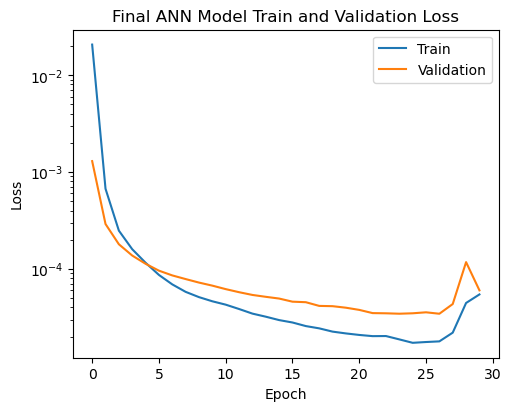

In [25]:
model_final = nn.Sequential(
    aev_computer,
    torchani.ANIModel([
        AtomicNetFinal(best_parameters[0]),
        AtomicNetFinal(best_parameters[0]),
        AtomicNetFinal(best_parameters[0]),
        AtomicNetFinal(best_parameters[0])
    ])
).to(device)

trainer_final = ANITrainer(
    model=model_final,
    batch_size=best_parameters[2],
    learning_rate=best_parameters[1],
    epoch=30,
    l2=0.0  # No L2 because dropout is being used
)

train_loss, val_loss = trainer_final.train(
    train_data=train_data,
    val_data=val_data,
    early_stop=True,
    draw_curve=True, 
    plot_title = "Final ANN Model Train and Validation Loss"
)


I chose to use dropout regularization because it performed better than using L2 and performed better than using both L2 and Dropout. I used hyperparameter tuning to get Dropout rate: 0.5, Learning rate: 0.001, and Batch size: 64 which gave me a validation loss of  0.000029.

## Checkpoint 4: Final Producton Mode


In [26]:
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

def cross_validate(model_class, dataset, k=5, batch_size=32, lr=0.01, epoch=30, dropout_rate=0.5):
    dataset = list(dataset)  # convert to list so we can index
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    fold_losses = []
    all_val_loss_lists = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
        print(f"\nFold {fold + 1}/{k}")

        train_split = [dataset[i] for i in train_idx]
        val_split = [dataset[i] for i in val_idx]

        train_data = torchani.data.TransformableIterable(train_split)
        val_data = torchani.data.TransformableIterable(val_split)

        model = nn.Sequential(
            aev_computer,
            torchani.ANIModel([
                model_class(dropout_rate),
                model_class(dropout_rate),
                model_class(dropout_rate),
                model_class(dropout_rate)
            ])
        ).to(device)

        trainer = ANITrainer(
            model=model,
            batch_size=batch_size,
            learning_rate=lr,
            epoch=epoch,
            l2=0.0
        )

        _, val_loss = trainer.train(train_data, val_data, draw_curve=False)
        all_val_loss_lists.append(val_loss)
        final_val_loss = val_loss[-1]
        fold_losses.append(final_val_loss)

    # Plotting validation losses
    plt.figure(figsize=(7, 5))
    for i, val_loss in enumerate(all_val_loss_lists):
        plt.plot(val_loss, label=f"Fold {i+1}")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("5-Fold Cross-Validation: Validation Loss per Fold")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\nAverage validation loss: {np.mean(fold_losses):.6f}")
    return fold_losses



Fold 1/5
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 30/30 [00:06<00:00,  4.31it/s]



Fold 2/5
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 30/30 [00:07<00:00,  4.15it/s]



Fold 3/5
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 30/30 [00:07<00:00,  4.08it/s]



Fold 4/5
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 30/30 [00:07<00:00,  3.99it/s]



Fold 5/5
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 30/30 [00:07<00:00,  4.14it/s]


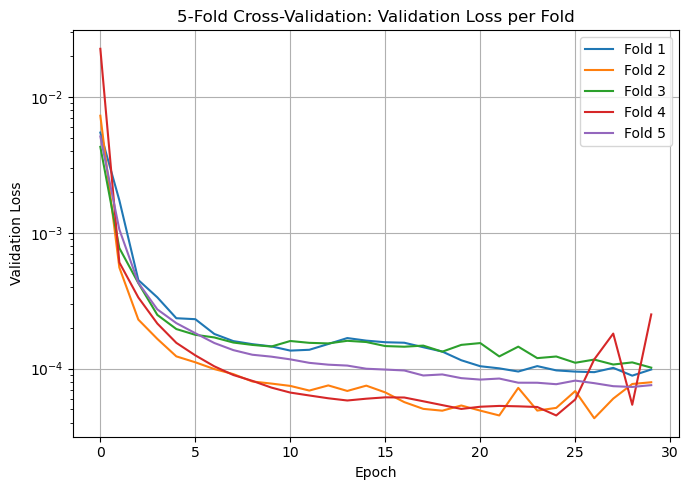


Average validation loss: 0.000121


[9.852534843957982e-05,
 7.932755048386752e-05,
 0.00010163894738070667,
 0.00025063448236323894,
 7.553020033810753e-05]

In [27]:
cross_validate(AtomicNetFinal, train_data, k=5, batch_size=32, lr=0.01, epoch=30, dropout_rate=0.5)



Run 1
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 30/30 [00:08<00:00,  3.63it/s]


Test Loss: 0.007387548102997243

Run 2
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 30/30 [00:08<00:00,  3.71it/s]


Test Loss: 0.041320373537018895

Run 3
Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 30/30 [00:09<00:00,  3.09it/s]


Test Loss: 0.015601921011693776


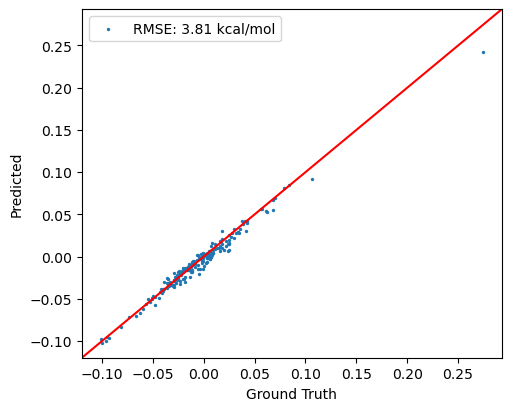

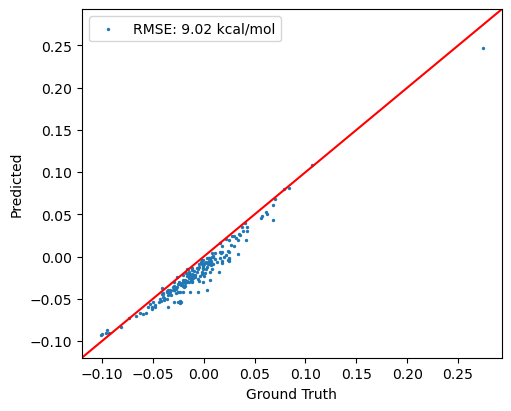

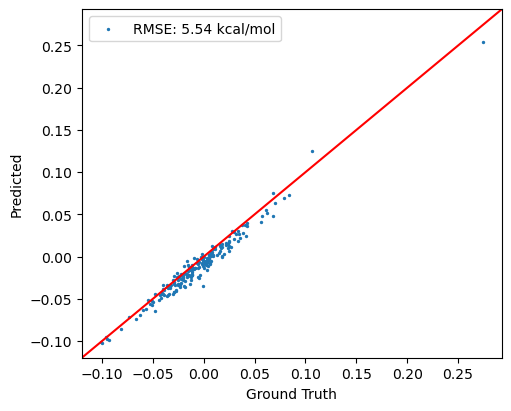

In [28]:
for run in range(3):
    print(f"\nRun {run + 1}")
    model = nn.Sequential(
        aev_computer,
        torchani.ANIModel([
            AtomicNetFinal(0.5),
            AtomicNetFinal(0.5),
            AtomicNetFinal(0.5),
            AtomicNetFinal(0.5)
        ])
    ).to(device)

    trainer = ANITrainer(
        model=model,
        batch_size=32,
        learning_rate=0.01,
        epoch=30,
        l2=0.0
    )

    trainer.train(train_data, val_data, early_stop=True, draw_curve=False)
    test_loss = trainer.evaluate(test_data, draw_plot=True)
    print("Test Loss:", test_loss)


## Checkpoint 1: Data preparation


Sequential - Number of parameters: 526340
Initialize training data...


100%|███████████████████████████████████████████| 30/30 [00:14<00:00,  2.14it/s]


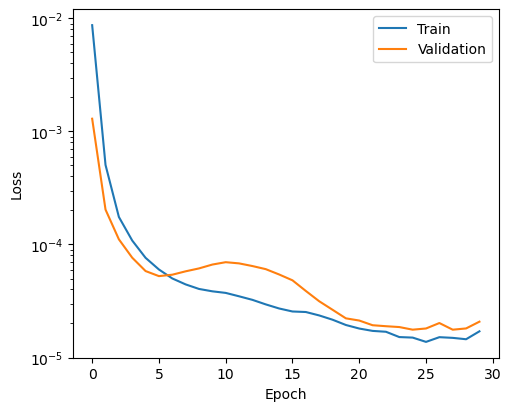

In [29]:
#  all data
full_data = list(train_data) + list(val_data) + list(test_data)
full_data = torchani.data.TransformableIterable(full_data)

# Define final model class
class AtomicNetAll(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.layers(x)


# Instantiate model with best hyperparameters
final_model = nn.Sequential(
    aev_computer,
    torchani.ANIModel([
        AtomicNetAll(0.5),
        AtomicNetAll(0.5),
        AtomicNetAll(0.5),
        AtomicNetAll(0.5)
    ])
).to(device)

# Set up trainer
trainer_full = ANITrainer(
    model=final_model,
    batch_size=best_parameters[2],
    learning_rate=best_parameters[1],
    epoch=30,
    l2=0.0
)



# Train the model (note: no validation here since it's full data)
train_loss, _ = trainer_full.train(
    train_data=full_data,
    val_data=full_data,  
    early_stop=False,
    draw_curve=True
)


In [30]:
print(f"Final training loss: {train_loss[-1]:.6f}")


Final training loss: 0.000017


Final RMSE: 2.859 kcal/mol


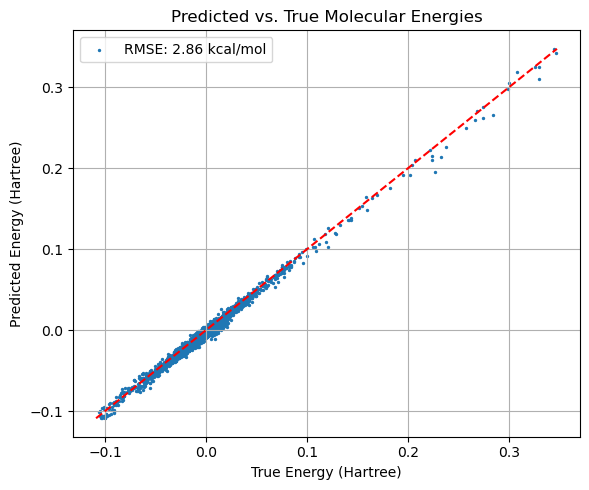

Final RMSE: 2.859 kcal/mol


In [31]:
hartree2kcalmol = 627.5094738898777

def compute_rmse(model, dataset, batch_size):
    model.eval()
    data_loader = dataset.collate(batch_size).cache()
    true_energies_all = []
    pred_energies_all = []

    with torch.no_grad():
        for batch in data_loader:
            species = batch['species'].to(next(model.parameters()).device)
            coordinates = batch['coordinates'].to(next(model.parameters()).device).float()
            true_energies = batch['energies'].to(next(model.parameters()).device).float()

            pred_energies = model((species, coordinates)).energies
            true_energies_all.append(true_energies.cpu().numpy().flatten())
            pred_energies_all.append(pred_energies.cpu().numpy().flatten())

    true_energies_all = np.concatenate(true_energies_all)
    pred_energies_all = np.concatenate(pred_energies_all)

    rmse = np.sqrt(np.mean((true_energies_all - pred_energies_all) ** 2)) * hartree2kcalmol
    print(f"Final RMSE: {rmse:.3f} kcal/mol")

    # Plot predicted vs. actual
    plt.figure(figsize=(6, 5))
    plt.scatter(true_energies_all, pred_energies_all, s=2, label=f"RMSE: {rmse:.2f} kcal/mol")
    plt.xlabel("True Energy (Hartree)")
    plt.ylabel("Predicted Energy (Hartree)")
    plt.title("Predicted vs. True Molecular Energies")
    plt.legend()
    plt.grid(True)

    # Plot y=x reference line
    min_val = min(true_energies_all.min(), pred_energies_all.min())
    max_val = max(true_energies_all.max(), pred_energies_all.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

    plt.tight_layout()
    plt.show()

    return rmse

rmse_final = compute_rmse(final_model, full_data, batch_size=64)
print(f"Final RMSE: {rmse_final:.3f} kcal/mol")



There is a very low training loss, which means my model is fitting pretty close to training data. In the ANI-1 paper, the model predicts molecular energies, and their performance is reported in kcal/mol RMSE. Their best training RMSE is 1.2 kcal/mol. My best was 2.383 kcal/mol. 